<a href="https://colab.research.google.com/github/Shreyansh260/pytorch-notebooks/blob/main/Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class BasicNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.w00 = nn.Parameter(torch.tensor(1.7),requires_grad=False)
    self.b00 = nn.Parameter(torch.tensor(-0.85),requires_grad=False)
    self.w01 = nn.Parameter(torch.tensor(-40.8),requires_grad=False)
    self.w10 = nn.Parameter(torch.tensor(12.6),requires_grad=False)
    self.b10 = nn.Parameter(torch.tensor(0.0),requires_grad=False)
    self.w11 = nn.Parameter(torch.tensor(2.7),requires_grad=False)

    self.final_bias = nn.Parameter(torch.tensor(-16.),requires_grad=False)
  def forward(self,input):
    input_to_top_relu = input*self.w00 + self.b00
    top_relu_output = F.relu(input_to_top_relu)
    scaled_top_relu_output = top_relu_output*self.w01

    input_to_bottom_relu = input*self.w10 + self.b10
    bottom_relu_output = F.relu(input_to_bottom_relu)
    scaled_bottom_relu_output = bottom_relu_output*self.w11
    input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

    output = F.relu(input_to_final_relu)
    return output


In [ ]:
input_doses = torch.linspace(start = 0, end = 1, steps = 11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

Text(0.5, 0, 'Dose')

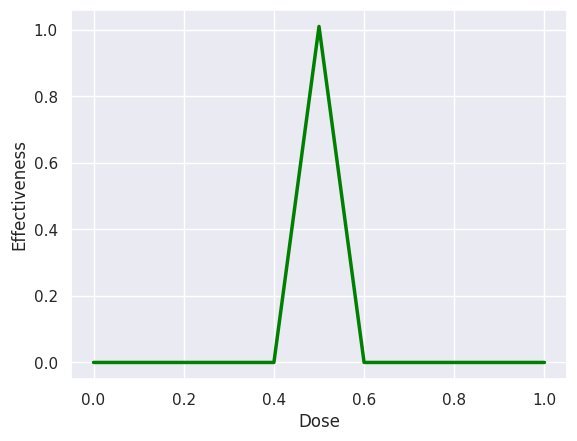

In [ ]:
model = BasicNN()
output_values = model(input_doses)
sns.set(style='darkgrid')
sns.lineplot(x=input_doses, y=output_values,color = 'green',linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")

In [ ]:
class BasicNN_train(nn.Module):
  def __init__(self):
    super().__init__()
    self.w00 = nn.Parameter(torch.tensor(1.7),requires_grad=False)
    self.b00 = nn.Parameter(torch.tensor(-0.85),requires_grad=False)
    self.w01 = nn.Parameter(torch.tensor(-40.8),requires_grad=False)
    self.w10 = nn.Parameter(torch.tensor(12.6),requires_grad=False)
    self.b10 = nn.Parameter(torch.tensor(0.0),requires_grad=False)
    self.w11 = nn.Parameter(torch.tensor(2.7),requires_grad=False)

    self.final_bias = nn.Parameter(torch.tensor(0.0),requires_grad=True)
  def forward(self,input):
    input_to_top_relu = input*self.w00 + self.b00
    top_relu_output = F.relu(input_to_top_relu)
    scaled_top_relu_output = top_relu_output*self.w01

    input_to_bottom_relu = input*self.w10 + self.b10
    bottom_relu_output = F.relu(input_to_bottom_relu)
    scaled_bottom_relu_output = bottom_relu_output*self.w11
    input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

    output = F.relu(input_to_final_relu)
    return output


Text(0.5, 0, 'Dose')

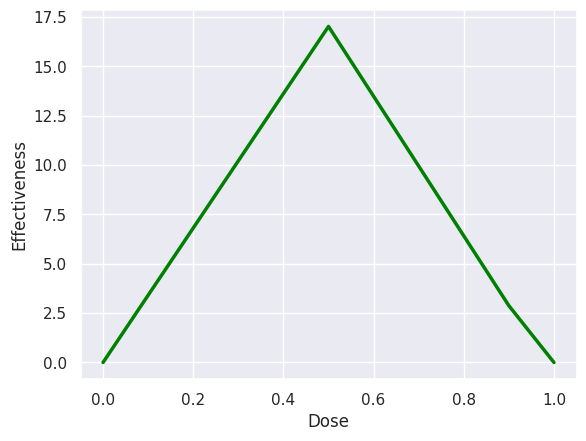

In [ ]:
model = BasicNN_train()
output_values = model(input_doses)
sns.set(style='darkgrid')
sns.lineplot(x=input_doses, y=output_values.detach(),color = 'green',linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")

In [ ]:
input = torch.tensor([0.0,0.5,1.0])
labels = torch.tensor([0.0,1.0,0.0])

In [ ]:
optimizer = SGD(model.parameters(),lr = 0.1)
print("Final Bias Before Optimization: "+ str(model.final_bias.data)+"\n")

Final Bias Before Optimization: tensor(0.)



In [ ]:
for epoch in range(100):
  total_loss = 0
  for i in range(len(input)):
    input_i = input[i]
    label_i = labels[i]

    output_i = model(input_i)
    loss = (output_i - label_i)**2
    loss.backward()
    total_loss += float(loss)

  if (total_loss<0.0001):
    print("NUm steps: "+ str(epoch))
    break

  optimizer.step()
  optimizer.zero_grad()
  print("Step: "+ str(epoch)+"Final bias after epoches: "+ str(model.final_bias.data)+"\n")



Step: 0Final bias after epoches: tensor(-3.2020)

Step: 1Final bias after epoches: tensor(-5.7636)

Step: 2Final bias after epoches: tensor(-7.8129)

Step: 3Final bias after epoches: tensor(-9.4523)

Step: 4Final bias after epoches: tensor(-10.7638)

Step: 5Final bias after epoches: tensor(-11.8131)

Step: 6Final bias after epoches: tensor(-12.6525)

Step: 7Final bias after epoches: tensor(-13.3240)

Step: 8Final bias after epoches: tensor(-13.8612)

Step: 9Final bias after epoches: tensor(-14.2909)

Step: 10Final bias after epoches: tensor(-14.6348)

Step: 11Final bias after epoches: tensor(-14.9098)

Step: 12Final bias after epoches: tensor(-15.1298)

Step: 13Final bias after epoches: tensor(-15.3059)

Step: 14Final bias after epoches: tensor(-15.4467)

Step: 15Final bias after epoches: tensor(-15.5594)

Step: 16Final bias after epoches: tensor(-15.6495)

Step: 17Final bias after epoches: tensor(-15.7216)

Step: 18Final bias after epoches: tensor(-15.7793)

Step: 19Final bias after e

Text(0.5, 0, 'Dose')

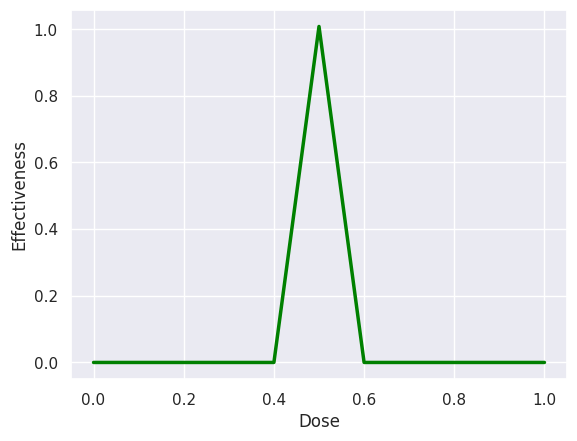

In [ ]:

output_values = model(input_doses)
sns.set(style='darkgrid')
sns.lineplot(x=input_doses, y=output_values.detach(),color = 'green',linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")